<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crimes          85 non-null     int64  
 1   consumer        85 non-null     int64  
 2   people          85 non-null     float64
 3   services        85 non-null     int64  
 4   budget          85 non-null     float64
 5   income          85 non-null     int64  
 6   unemployed      85 non-null     float64
 7   cost_of_living  85 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 5.4 KB
None
              crimes      consumer        people      services        budget  \
count      85.000000     85.000000     85.000000     85.000000  8.500000e+01   
mean    23572.529412  27548.705882   1712.441176  27548.705882  2.063843e+05   
std     21835.643802   8225.004171   1810.019548   8225.004171  3.777181e+05   
min       686.000000  10468.000000     44.500000  10468.000000  2.349620e


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


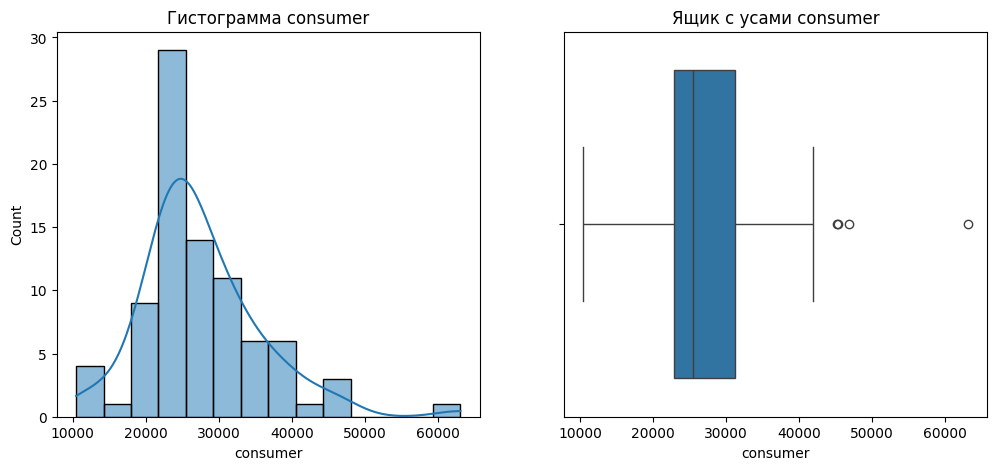

consumer:
 Среднее: 27548.70588235294
 Медиана: 25438.0
 Стандартное отклонение: 8225.004171114197
 Размах: 52634
 Асимметрия: 1.219942488032424
 Эксцесс: 3.513289660587422


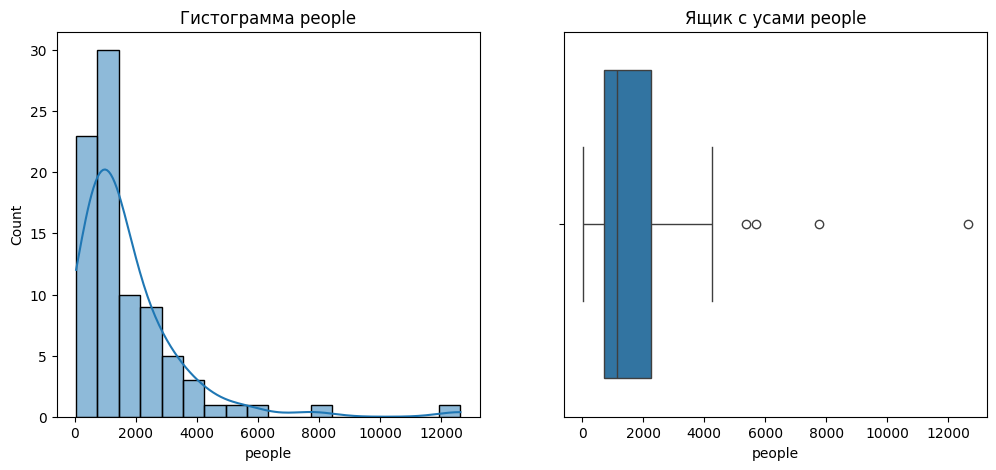

people:
 Среднее: 1712.4411764705878
 Медиана: 1139.5
 Стандартное отклонение: 1810.0195477959242
 Размах: 12591.0
 Асимметрия: 3.394465688344106
 Эксцесс: 16.239480447607715


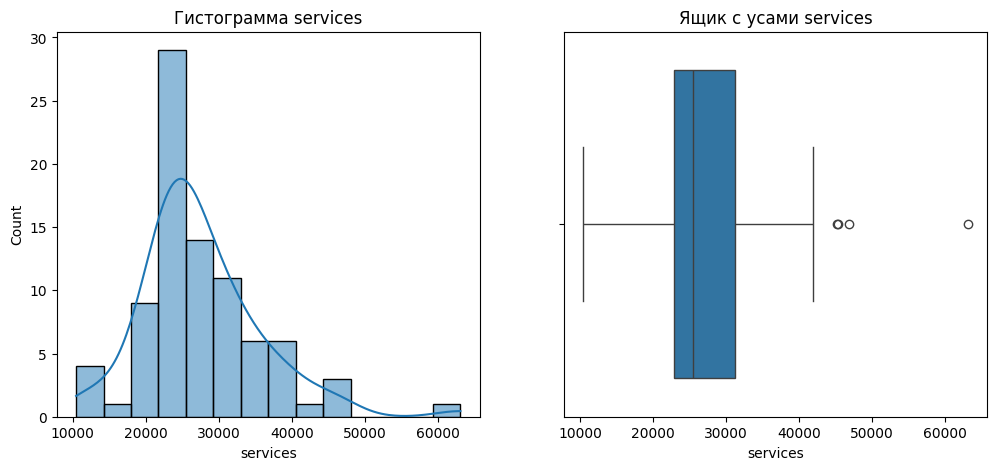

services:
 Среднее: 27548.70588235294
 Медиана: 25438.0
 Стандартное отклонение: 8225.004171114197
 Размах: 52634
 Асимметрия: 1.219942488032424
 Эксцесс: 3.513289660587422


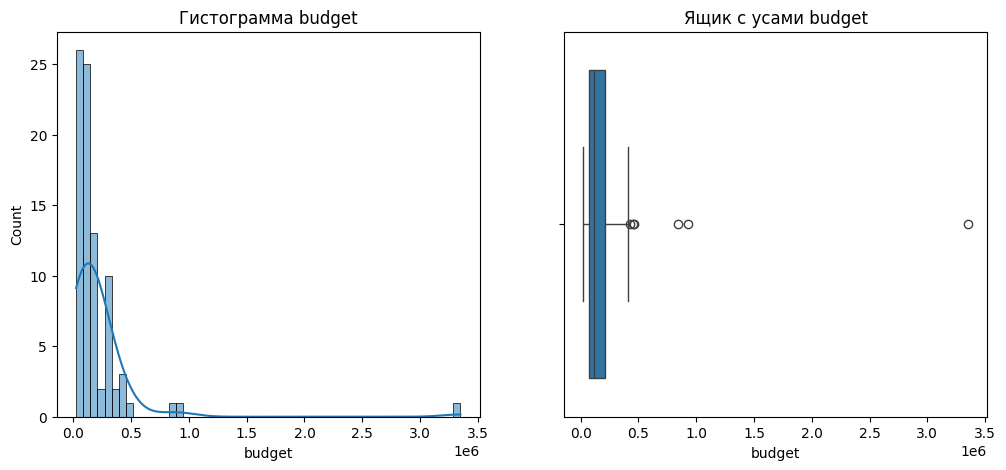

budget:
 Среднее: 206384.3329411765
 Медиана: 118579.2
 Стандартное отклонение: 377718.1340134654
 Размах: 3325914.9
 Асимметрия: 7.156298935260664
 Эксцесс: 58.48489815443947


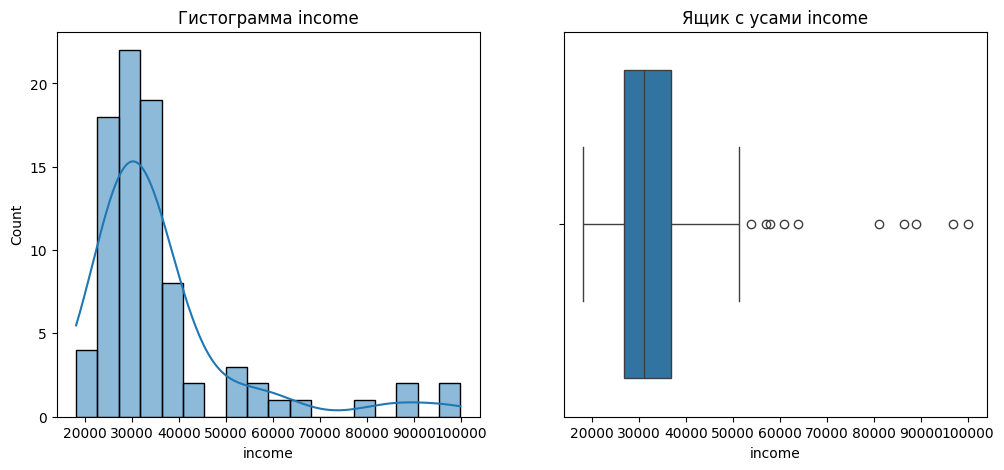

income:
 Среднее: 36252.67058823529
 Медиана: 30976.0
 Стандартное отклонение: 16352.869701842372
 Размах: 81766
 Асимметрия: 2.399460218238711
 Эксцесс: 5.825865566346312


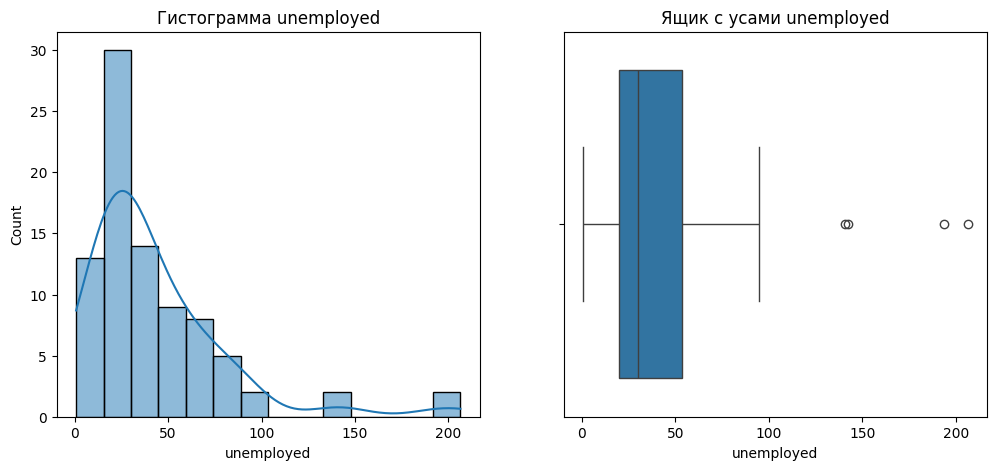

unemployed:
 Среднее: 42.70823529411765
 Медиана: 30.1
 Стандартное отклонение: 37.29090024250364
 Размах: 205.6
 Асимметрия: 2.281244970089976
 Эксцесс: 6.690664635667751


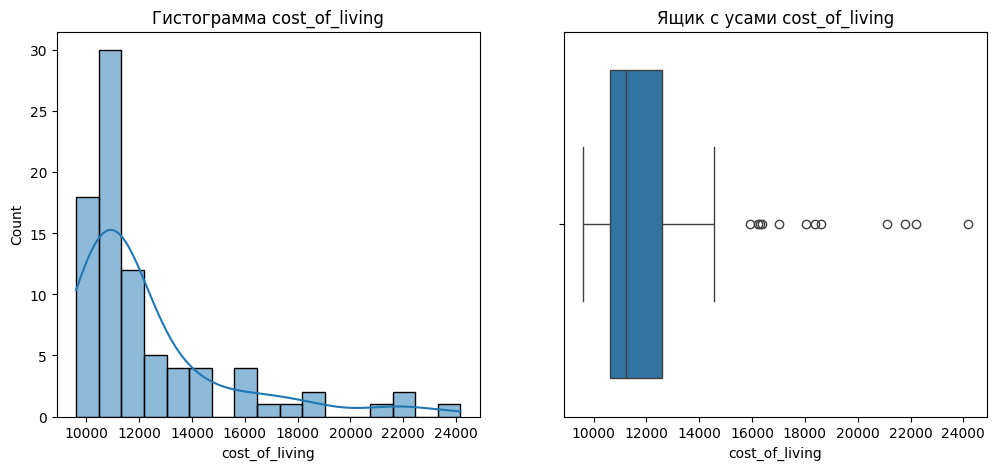

cost_of_living:
 Среднее: 12318.480705882354
 Медиана: 11206.0
 Стандартное отклонение: 3054.0935400594444
 Размах: 14554.0
 Асимметрия: 2.0859567472602394
 Эксцесс: 4.162228859115169
R2 Score (after improvements): 0.8060945977414353
RMSE (after improvements): 6846.140559702048


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [43]:
!pip install openpyxl

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, f1_score, roc_auc_score
from scipy.stats import zscore, boxcox

# Загрузка данных
data = pd.read_excel("C:/Users/user/Desktop/Data.xlsx")

# Просмотр информации о данных
print(data.info())
print(data.describe())

# 1. Выбор зависимой переменной (целевая переменная)
# Предположим, что 'crimes' — это зависимая переменная, если известна структура данных
target = 'crimes'
X = data.drop(columns=[target])
y = data[target]

# 2. Обучение базовой модели
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Выбор модели (например, линейная регрессия для регрессионной задачи)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Оценка производительности для регрессии
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Для классификации
# model = LogisticRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:, 1]
# print("F1 Score:", f1_score(y_test, y_pred))
# print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

# 3. Одномерный анализ данных
for col in X.columns:
    plt.figure(figsize=(12, 5))
    
    # Гистограмма и ящик с усами
    plt.subplot(1, 2, 1)
    sns.histplot(X[col].dropna(), kde=True)
    plt.title(f"Гистограмма {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=X[col])
    plt.title(f"Ящик с усами {col}")
    plt.show()

    # Описательная статистика
    print(f"{col}:")
    print(" Среднее:", X[col].mean())
    print(" Медиана:", X[col].median())
    print(" Стандартное отклонение:", X[col].std())
    print(" Размах:", X[col].max() - X[col].min())
    print(" Асимметрия:", X[col].skew())
    print(" Эксцесс:", X[col].kurtosis())

# 4. Обработка пропущенных значений
X = X.fillna(X.mean())  # Например, замена пропущенных значений на средние

# 5. Обнаружение и устранение выбросов
# Используем Z-score для нахождения выбросов
threshold = 3
for col in X.columns:
    X = X[(np.abs(zscore(X[col])) < threshold)]
y = y.loc[X.index]

# 6. Преобразование переменных для нормализации
for col in X.columns:
    if X[col].skew() > 1:  # Проверка на асимметрию
        X[col], _ = boxcox(X[col] + 1)  # Преобразование Box-Cox

# 7. Масштабирование данных (если необходимо)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Повторное обучение модели после обработки данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Оценка производительности после улучшений
print("R2 Score (after improvements):", r2_score(y_test, y_pred))
print("RMSE (after improvements):", mean_squared_error(y_test, y_pred, squared=False))
